In [1]:
import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
#from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])

i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-04 18:15:00,512 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2025-03-04 18:15:00,516 - INFO - Succeeded to open the port
2025-03-04 18:15:00,519 - INFO - Succeeded to change the baudrate
2025-03-04 18:15:00,525 - INFO - Servo 1x: SCServo acc set!
2025-03-04 18:15:00,531 - INFO - Servo 1x: SCServo speed set!
2025-03-04 18:15:00,536 - INFO - Servo 1x: SCServo acc set!
2025-03-04 18:15:00,541 - INFO - Servo 1x: SCServo speed set!
2025-03-04 18:15:00,550 - INFO - Servo 1y: SCServo acc set!
2025-03-04 18:15:00,555 - INFO - Servo 1y: SCServo speed set!
2025-03-04 18:15:00,560 - INFO - Servo 1y: SCServo acc set!
2025-03-04 18:15:00,565 - INFO - Servo 1y: SCServo speed set!
2025-03-04 18:15:00,574 - INFO - Servo 2x: SCServo acc set!
2025-03-04 18:15:00,579 - INFO - Servo 2x: SCServo speed set!
2025-03-04 18:15:00,584 - INFO - Servo 2x: SCServo acc set!
2025-03-04 18:15:00,590 - INFO - Servo 2x: SCServo speed set!
2025-03-04 18:15:00,599 - INFO - Servo 2y: SCServo acc

[Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'


2025-03-04 18:15:00,715 - INFO - Servo 4y: SCServo speed set!
2025-03-04 18:15:00,721 - INFO - loading position from disk
2025-03-04 18:15:00,722 - INFO - Loaded, the positions are: 
Servo 1x: -0.52734375 deg	Servo 1y: -0.439453125 deg	Servo 2x: -0.439453125 deg	Servo 2y: -0.615234375 deg	Servo 3x: 0.0 deg	Servo 3y: 0.0 deg	Servo 4x: 0.0 deg	Servo 4y: -0.87890625 deg	


In [3]:
servos.home()
servos.torques_disable()

2025-03-03 17:33:21,076 - INFO - going home


In [8]:
servos.set_zero()

2025-03-03 17:54:06,389 - INFO - Setting Zero
2025-03-03 17:54:06,401 - INFO - Servo 1x: SCServo zero set!
2025-03-03 17:54:06,437 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,472 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,473 - INFO - Servo 1y: SCServo zero set!
2025-03-03 17:54:06,484 - INFO - Servo 2x: SCServo zero set!
2025-03-03 17:54:06,495 - INFO - Servo 2y: SCServo zero set!
2025-03-03 17:54:06,531 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,537 - ERROR - Servo 3x: Read not sucessful!
2025-03-03 17:54:06,573 - INFO - Servo 3x: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,574 - INFO - Servo 3x: SCServo zero set!
2025-03-03 17:54:06,609 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,615 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,621 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,657 - INFO - Servo 3y: result [TxRxResult]

In [ ]:
#servos.set_zero()
servos.torques_disable()

In [3]:
print(MCP3424_fiber.convert_and_read())

1.491


reference


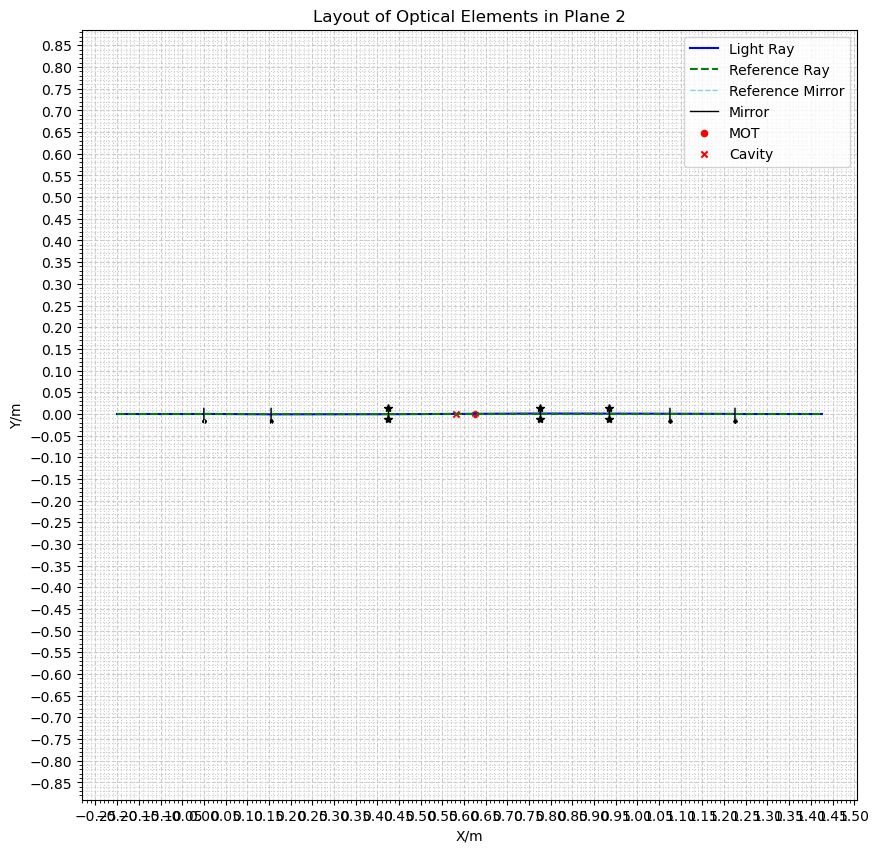

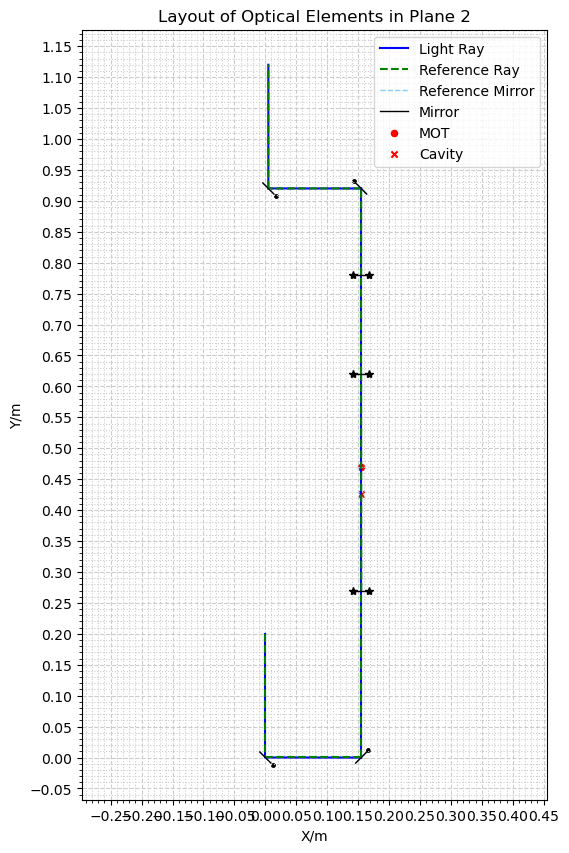

[-147.69734510880116, 171.09760924530318, -13.712233028151207, 60.55474931437654]
[-24.012038290095365, -24.012038290095365, -15.904428833260887, -18.69571803396342]
[24.012038290095365, -147.69734510880116, 24.012038290095365, 171.09760924530318, 15.904428833260887, -13.712233028151207, 18.69571803396342, 60.55474931437654]


In [ ]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2
solver_0.xy=1

print('reference')
Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params_2, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=1)
print([Mrr1_y.knob_deg(), Mrr2_y.knob_deg(), Mrr3_y.knob_deg(), Mrr4_y.knob_deg()])
print([Mrr1_x.knob_deg(), Mrr2_x.knob_deg(), Mrr3_x.knob_deg(), Mrr4_x.knob_deg()])
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)

In [34]:
servos.set_angle(knob_deg_list)
print(MCP3424_fiber.convert_and_read())

1.5210000000000001


In [4]:
servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-04 18:15:09,781 - INFO - going home


1.491


In [12]:
print(MCP3424_fiber.convert_and_read())
servos.get_angle()

1.489


array([-0.52734375, -0.43945312, -0.43945312, -0.52734375,  0.        ,
        0.        ,  0.        ,  0.        ])

# Angle sweeping

In [1]:
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servoaligner")

import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import xarray as xr

import multiprocessing
import os
import time
from tqdm import tqdm
import numpy as np

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iterator_compute import angle_calc_multi, scan_xarray_gen

In [2]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [ ]:
solver_0=Optical_system_solver()
scan_xr=scan_xarray_gen(var_str_list=['fl1','fl2','MOT_pos_1','MOT_pos_2'], range_list=[1e-2, 1e-2, 2e-4, 2e-4], num_list=[5,5,10,10], start_value_list=[fl1, MOT_pos_1, MOT_pos_2])

100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


In [5]:
import os
os.chdir("//home//rydpi5//expctl//servers//servoaligner")
scan_xr=xr.open_dataarray("angles0304_3.nc")

In [6]:
scan_xr

<xarray.DataArray (fl1: 5, fl2: 5, MOT_pos_1: 10, MOT_pos_2: 10, knobs: 8)>
[20000 values with dtype=float64]
Coordinates:
  * MOT_pos_1  (MOT_pos_1) float64 -0.0002 -0.0001556 ... 0.0001556 0.0002
  * MOT_pos_2  (MOT_pos_2) float64 0.0 4.444e-05 8.889e-05 ... 0.0003556 0.0004
  * knobs      (knobs) object 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'
  * fl1        (fl1) float64 0.1875 0.19 0.1925 0.195 0.1975
  * fl2        (fl2) float64 0.145 0.1475 0.15 0.1525 0.155

In [ ]:
ds=iteration_actuator(servos, MCP3424_fiber, scan_xr)
ds.to_netcdf("data0304_2.nc")

100%|██████████| 500/500 [08:38<00:00,  1.04s/it]
2025-03-04 17:20:19,490 - INFO - going home


1.491


In [8]:
import os
os.chdir("//home//rydpi5//expctl//servers//servoaligner")
ds=xr.open_dataset("data0304_2.nc")

In [14]:
ds

<xarray.Dataset>
Dimensions:      (MOT_pos_1: 10, MOT_pos_2: 10, knobs: 8, fl1: 5, fl2: 5)
Coordinates:
  * MOT_pos_1    (MOT_pos_1) float64 -0.0002 -0.0001556 ... 0.0001556 0.0002
  * MOT_pos_2    (MOT_pos_2) float64 0.0 4.444e-05 ... 0.0003556 0.0004
  * knobs        (knobs) object 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'
  * fl1          (fl1) float64 0.1875 0.19 0.1925 0.195 0.1975
  * fl2          (fl2) float64 0.145 0.1475 0.15 0.1525 0.155
Data variables:
    knob_angles  (fl1, fl2, MOT_pos_1, MOT_pos_2, knobs) float64 ...
    data         (fl1, fl2, MOT_pos_1, MOT_pos_2) float64 1.384 0.065 ... 0.041

In [9]:
ds['data'].sum('MOT_pos_1').sum('MOT_pos_2')

<xarray.DataArray 'data' (fl1: 5, fl2: 5)>
array([[ 93.93 ,  97.958, 101.29 , 105.574, 111.113],
       [ 95.186,  97.689, 100.771, 104.983, 109.944],
       [ 95.115,  97.67 , 100.641, 104.834, 109.871],
       [ 94.823,  97.466, 100.52 , 104.398, 109.399],
       [ 94.722,  97.349, 100.215, 103.883, 108.574]])
Coordinates:
  * fl1      (fl1) float64 0.1875 0.19 0.1925 0.195 0.1975
  * fl2      (fl2) float64 0.145 0.1475 0.15 0.1525 0.155

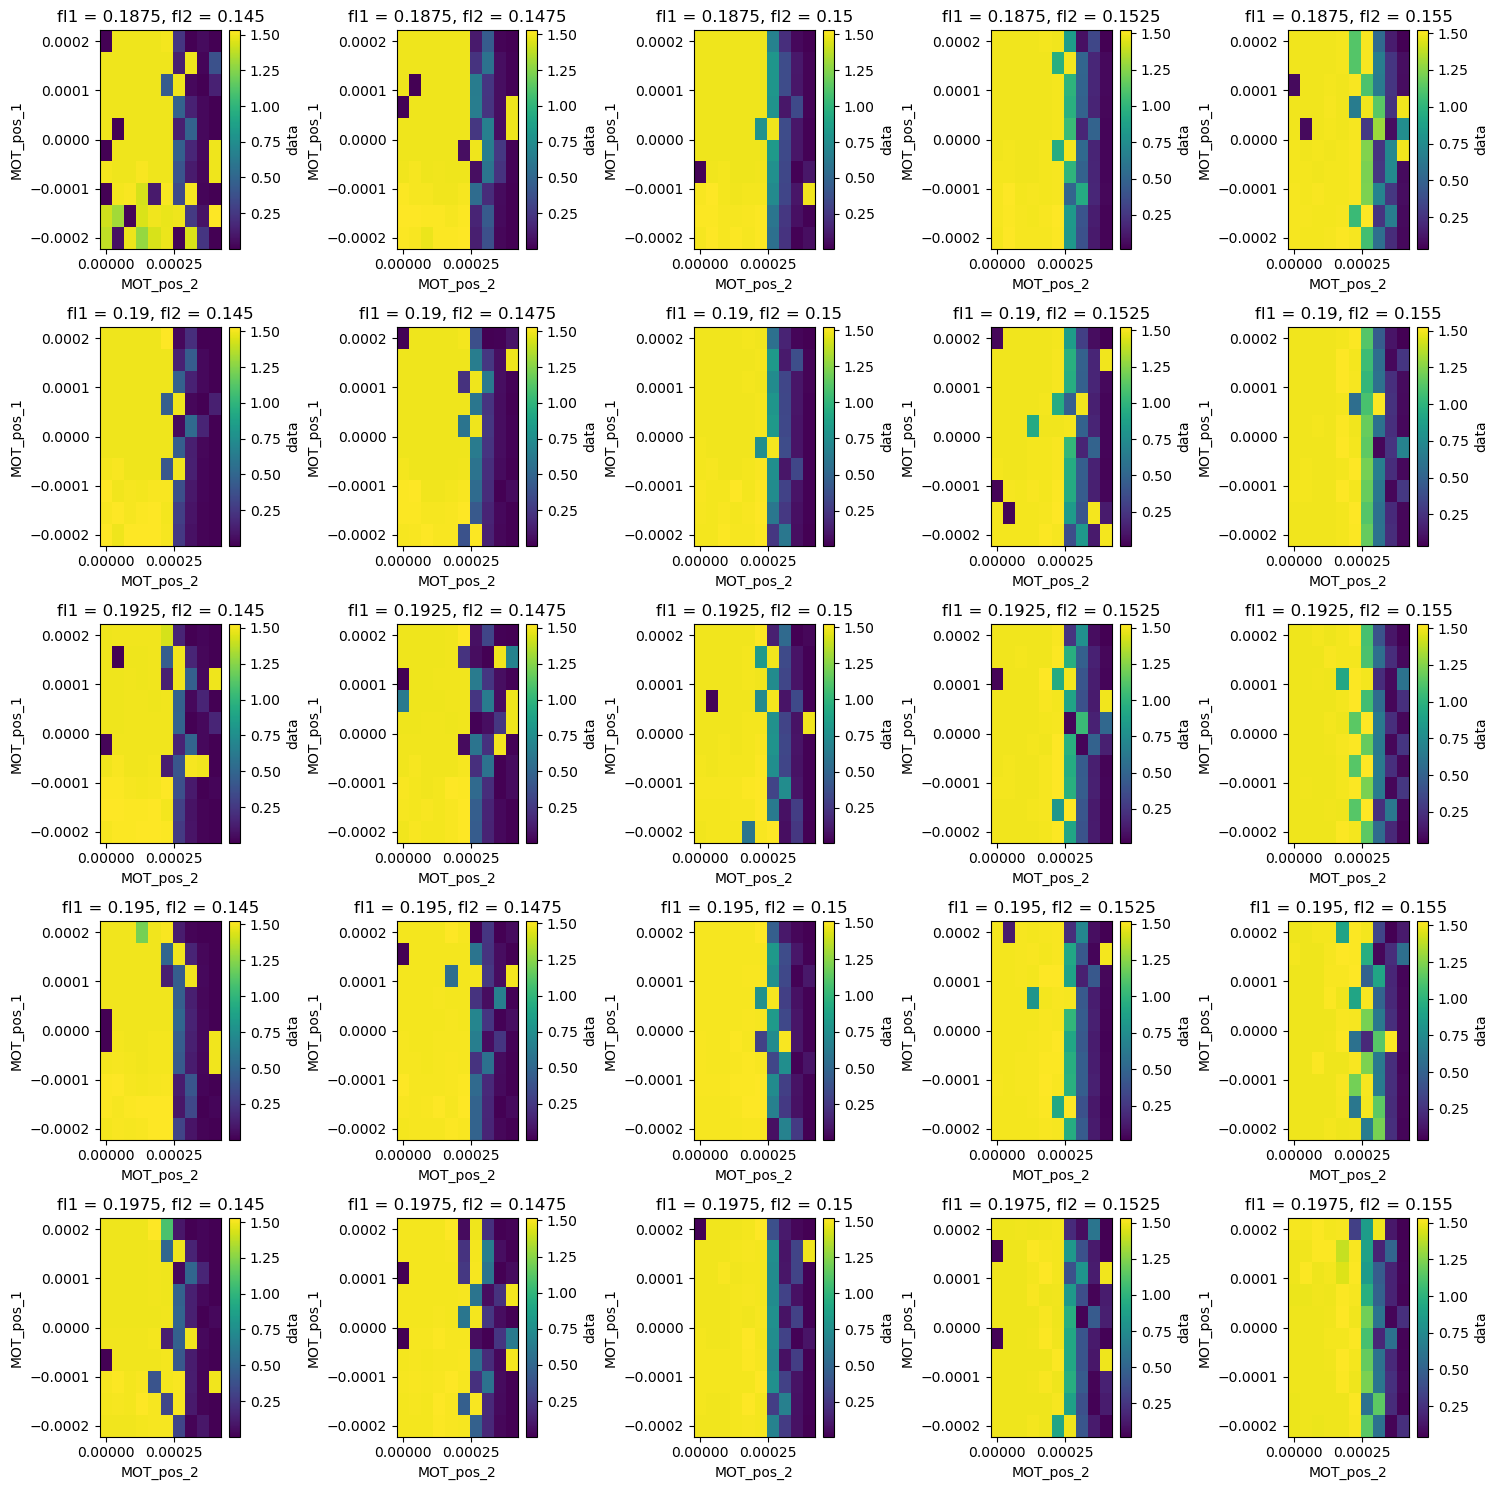

In [13]:
fig,axs=plt.subplots(5,5,figsize=(15,15)) 
for i in range(5):
    for j in range(5):
        ds['data'].isel(fl1=i, fl2=j).plot(ax=axs[i,j])
fig.tight_layout()
plt.show()

In [ ]:
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servoaligner\\expctl\\servers\\servoaligner")
result_xr=xr.open_dataarray("angles0303.nc")

In [7]:
servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-04 10:51:26,844 - INFO - going home


1.49


In [8]:
servos.home()
print(MCP3424_fiber.convert_and_read())

data_list=[]
for i in tqdm(range(len(result))):
    servos.set_angle(result[i])
    data_list.append(MCP3424_fiber.convert_and_read())

servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-04 10:51:27,742 - INFO - going home


1.49


100%|██████████| 100/100 [01:52<00:00,  1.12s/it]
2025-03-04 10:53:20,222 - INFO - going home


1.489


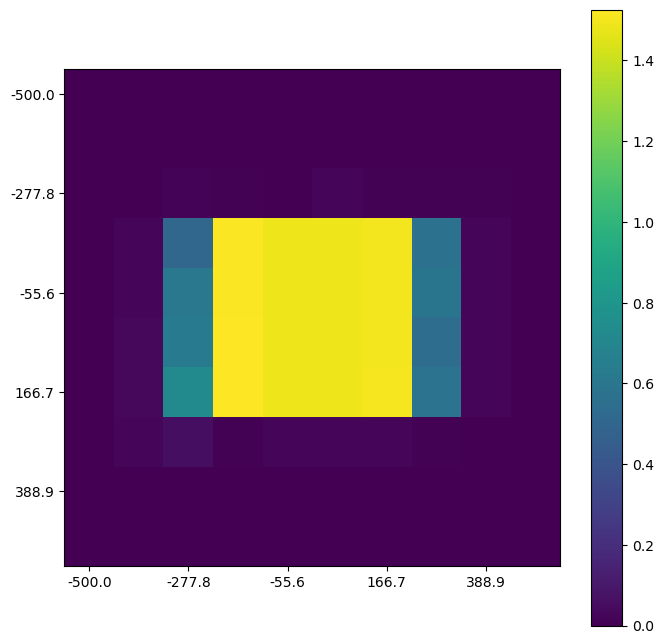

In [ ]:
data_list=np.reshape(data_list, (N_x,N_y))

plt.figure(figsize=(8,8))
plt.imshow(data_list)
plt.xticks(np.arange(N_x)[::2],np.round(1e6*x_array,1)[::2])
plt.yticks(np.arange(N_y)[::2],np.round(1e6*y_array,1)[::2])
plt.colorbar()
plt.show()

In [13]:
data_list_norm=data_list/np.max(data_list)
np.sum(data_list_norm)

19.164482306684143

# Real Setup

In [5]:
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servoaligner")

import sympy
from sympy import symbols, sin, cos, Add
from sympy import Matrix, nsolve, nsimplify
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens

In [ ]:
#numerical values
#-----------------------------------------------------
#plane 1
#-----------------------------------------------------
#mirror spacing
x1_1 = 0.15
x2_1 = 0.15
x3_1 = 0.15
x4_1 = 0.15
#lens spacing
dy0_1 = 0.1
dy1_1 = 0.4
dy2_1 = 0.15
dy3_1 = 0.15
#focal length
fl1_1 = 0.3
fl2_1 = 0.1
fl3_1 = 1
#MOT and Cavity
MOT_pos_1=1e-3
Cav_pos_1=-1e-3

#-----------------------------------------------------
#plane 2
#-----------------------------------------------------
#mirror spacing
x1_2 = 0.15
x2_2 = 0.15
x3_2 = 0.15
x4_2 = 0.15
#lens spacing
dy0_2 = 0.1
dy1_2 = 0.4
dy2_2 = 0.15
dy3_2 = 0.15
#focal length
fl1_2 = 0.3
fl2_2 = 0.1
fl3_2 = 1
#MOT and Cavity
MOT_pos_2=5e-4
Cav_pos_2=-5e-4

MOT_Cav_dist = 0.04

params_1={'x1':x1_1, 'x2':x2_1, 'x3': x3_1, 'x4':x4_1, 'dy0':dy0_1, 'dy1':dy1_1, 'dy2': dy2_1, 'dy3': dy3_1, 'fl1': fl1_1, 'fl2': fl2_1, 'fl3': fl3_1, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_1, 'Cav_pos': Cav_pos_1}
params_2={'x1':x1_2, 'x2':x2_2, 'x3': x3_2, 'x4':x4_2, 'dy0':dy0_2, 'dy1':dy1_2, 'dy2': dy2_2, 'dy3': dy3_1, 'fl1': fl1_2, 'fl2': fl2_2, 'fl3': fl3_2, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos': MOT_pos_2, 'Cav_pos': Cav_pos_2}

In [7]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2
solver_0.xy=0
solver_0.plot_size=(10,10)
Mrr1_1, Mrr2_1, Mrr3_1, Mrr4_1 = solver_0.real_setup_solver_1(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
solver_1=Optical_system_solver()
solver_1.init_ray_length=0.2
solver_1.xy=1
solver_1.plot_size=(10,10)
Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2 = solver_1.real_setup_solver_2(params=params_1, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
Mrr_list=[Mrr1_1, Mrr2_1, Mrr3_1, Mrr4_1, Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2]
for Mrr in Mrr_list:
    print(Mrr.knob_deg())

KeyError: 'MOT_pos_1'

In [2]:
# import os
# os.chdir('//Users//libowen//Desktop//servoserver//servotest//src')
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servo_np\\servotest\\src\\expctl\\servers\\servoaligner")

import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import xarray as xr

import multiprocessing
import os
import time
from tqdm import tqdm
import numpy as np

from solver_plotter import Optical_system_solver, Mirror, Lens

In [5]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [10]:
%matplotlib qt
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2

Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
print([Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl])
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=1)
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)

[-5.98723195071018e-11, 2.1312328034574983e-10, -9.653388209357737e-12, 2.1292674531456012e-10]
[-20.10564134781284, -2.8020245529323645e-06, -73.35881203519487, 9.974169520181092e-06, -11.55940812389815, -4.517785681979421e-07, -81.86165261634369, 9.964971680721414e-06]


In [1]:
# import os
# os.chdir('//Users//libowen//Desktop//servoserver//servotest//src')
import os
os.chdir("C:\\Users\\simonlab\\Documents\\Bowen\\servo_np\\servotest\\src\\expctl\\servers\\servoaligner")

import xarray as xr

import multiprocessing
import os
import time
from tqdm import tqdm
import numpy as np

from solver_plotter_np import Optical_system_solver, Mirror, Lens
from model_setting import params

In [8]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.35
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.2
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [9]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_0.init_ray_length=0.2

Mrr1_y, Mrr2_y, Mrr3_y, Mrr4_y = solver_0.default_setup_solver_y(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=0)
solver_0.plot_size=(6,10)
Mrr1_x, Mrr2_x, Mrr3_x, Mrr4_x = solver_0.default_setup_solver(params=params, tl_list=[0, 0, 0, 0], comp_list=[Mrr1_y.tl, Mrr2_y.tl, Mrr3_y.tl, Mrr4_y.tl], plot_switch=0)
knob_deg_list=[Mrr1_x.knob_deg(), Mrr1_y.knob_deg(), Mrr2_x.knob_deg(), Mrr2_y.knob_deg(), Mrr3_x.knob_deg(), Mrr3_y.knob_deg(), Mrr4_x.knob_deg(), Mrr4_y.knob_deg()]
print(knob_deg_list)

[-0.0, 0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0]
